In [45]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
from aquarel import load_theme

PATH_NAME_CLEANED = Path("../data/processed/spaceship_titanic_cleaned.csv")
PATH_NAME_FEATURE_ENGINEERED = Path("../data/processed/spaceship_titanic_feature_engineered.csv")

df_cleaned = pd.read_csv(PATH_NAME_CLEANED)
df_fe = pd.read_csv(PATH_NAME_FEATURE_ENGINEERED)

In [46]:
# look at the cleaned df
df_cleaned.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Surname,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Santantines,True


In [47]:
# summarize stats
df_cleaned.describe(include=["float64"]).round(2)

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8693.00,8693.00,8693.00,8693.00,8693.00,8693.00
mean,28.79,220.01,448.43,169.57,304.59,298.26
std,14.34,660.52,1595.79,598.01,1125.56,1134.13
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,20.00,0.00,0.00,0.00,0.00,0.00
50%,27.00,0.00,0.00,0.00,0.00,0.00
75%,37.00,41.00,61.00,22.00,53.00,40.00
max,79.00,14327.00,29813.00,23492.00,22408.00,24133.00


# Cleaned Dataset Analysis

## Target Variable Analysis

Is Transported balanced?

In [48]:
df_cleaned.Transported.value_counts()

Transported
True     4378
False    4315
Name: count, dtype: int64

What percentage was transported?

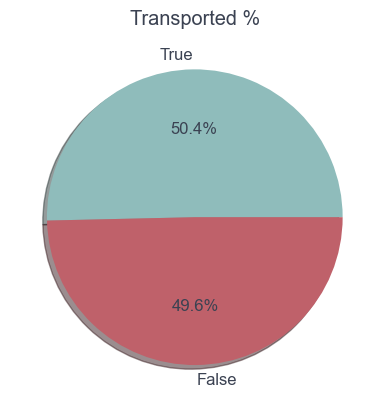

In [49]:
theme = load_theme("arctic_light")
theme.apply()

percTransported = df_cleaned.Transported.value_counts(normalize=True).reset_index()

plt.pie(percTransported.proportion, labels=percTransported.Transported, autopct="%1.1f%%", shadow=True)
plt.title("Transported %")
plt.show()

## Missing Values Review

Verify "unknown" count

In [50]:
(df_cleaned == "Unknown").sum().sort_values(ascending=False)

Surname         200
Cabin           199
HomePlanet        0
CryoSleep         0
Destination       0
PassengerId       0
Age               0
VIP               0
FoodCourt         0
RoomService       0
ShoppingMall      0
Spa               0
VRDeck            0
Transported       0
dtype: int64

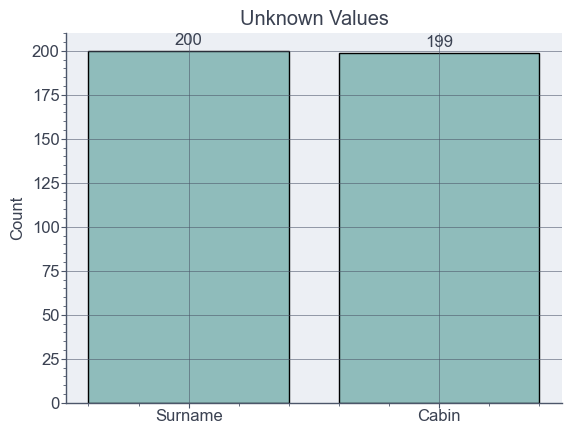

In [51]:
surname_unknowns = (df_cleaned.Surname == "Unknown").sum()
cabin_unknowns = (df_cleaned.Cabin == "Unknown").sum()
unknown_labels = ["Surname", "Cabin"]

unknown_bar_chart = plt.bar(unknown_labels, [surname_unknowns, cabin_unknowns], edgecolor="black")
plt.bar_label(unknown_bar_chart, padding=2)
plt.ylabel("Count")
plt.title("Unknown Values")
plt.show()

## Numerical Feature Distributions

Is Age skewed?

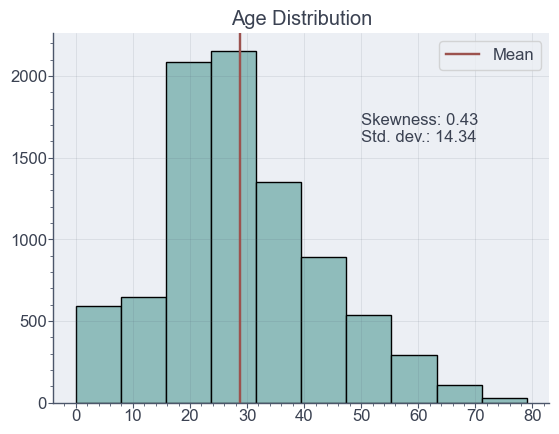

In [52]:
age_stats = df_cleaned.Age.agg(func=["mean", "skew", np.std]).reset_index()

plt.hist(df_cleaned.Age, edgecolor="black")
plt.axvline(age_stats.iloc[0, 1], ymin=0, color="#9c524e", label="Mean")
plt.text(x=50, y=1700, s=f"Skewness: {round(age_stats.iloc[1, 1], 2)}")
plt.text(x=50, y=1600, s=f"Std. dev.: {round(age_stats.iloc[2, 1], 2)}")
plt.grid(alpha=0.2)
plt.title("Age Distribution")
plt.legend()
plt.show()

Are children more likely to get transported?

In [53]:
age_groups = ["Child", "Teen", "Young Adult", "Adult", "Senior"]
age_bins = [0, 12, 18, 30, 50, 80]
df_cleaned["Age group"] = pd.cut(df_cleaned.Age, bins=age_bins, labels=age_groups)

pd.crosstab(df_cleaned["Age group"], df_cleaned.Transported, normalize="index")

Transported,False,True
Age group,,
Child,0.331210,0.668790
Teen,0.462701,0.537299
Young Adult,0.529997,0.470003
Adult,0.520568,0.479432
Senior,0.515604,0.484396


# Featured Engineered Dataset

In [54]:
# look at the feat. eng. dataset
df_fe.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,...,Group number,Passengers within group,Total spend,Group size,Is alone,No spending,Luxury spending,Basic spending,Spending per person,Transported
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,...,1,1,0.0,1,True,True,0.0,0.0,0.0,False
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,...,2,1,736.0,1,True,False,593.0,34.0,736.0,True
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,...,3,1,10383.0,2,False,False,6764.0,3576.0,5191.5,False
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,...,3,2,5176.0,2,False,False,3522.0,1654.0,2588.0,False
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,...,4,1,1091.0,1,True,False,567.0,221.0,1091.0,True


## Numerical Feature Distributions

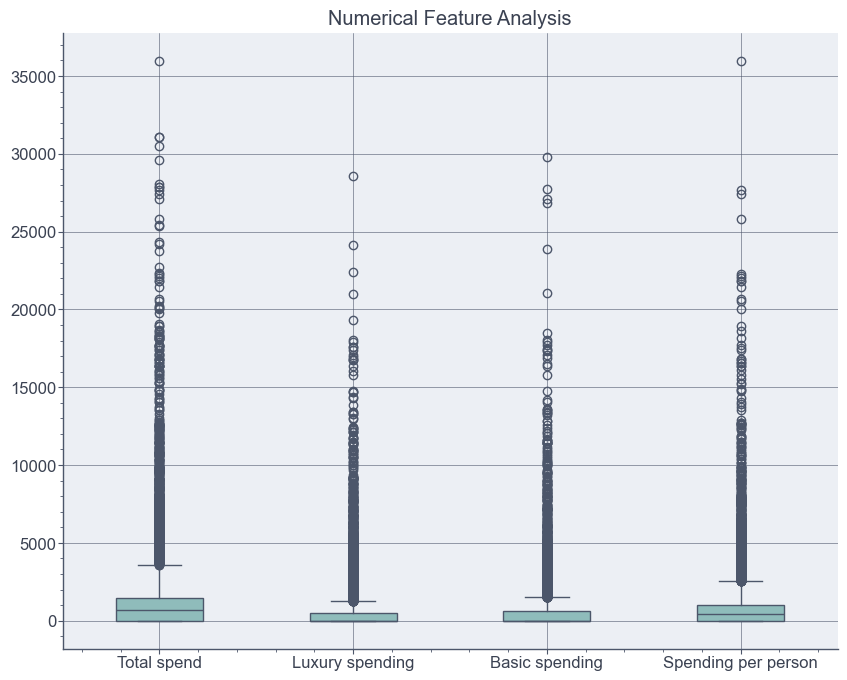

In [55]:
plt.figure(figsize=(10, 8))
fe_num_labels = ["Total spend", "Luxury spending", "Basic spending", "Spending per person"]

plt.boxplot([df_fe["Total spend"], df_fe["Luxury spending"], df_fe["Basic spending"], df_fe["Spending per person"]], 
            patch_artist=True, tick_labels=fe_num_labels)
plt.title("Numerical Feature Analysis")
plt.show()

## Categorical Feature Analysis

In [56]:
# planet and transported
pd.crosstab(df_fe.HomePlanet, df_fe.Transported, normalize="index")

Transported,False,True
HomePlanet,,
Earth,0.572351,0.427649
Europa,0.341154,0.658846
Mars,0.476976,0.523024


In [57]:
# destination and transported
pd.crosstab(df_fe.Destination, df_fe.Transported, normalize="index")

Transported,False,True
Destination,,
55 Cancri e,0.390000,0.610000
PSO J318.5-22,0.496231,0.503769
TRAPPIST-1e,0.527801,0.472199


In [58]:
# VIP and transported
pd.crosstab(df_fe.VIP, df_fe.Transported, normalize="index")

Transported,False,True
VIP,,
False,0.493525,0.506475
True,0.618090,0.381910


In [59]:
# cryo sleep and transported
pd.crosstab(df_fe.CryoSleep, df_fe.Transported, normalize="index")

Transported,False,True
CryoSleep,,
False,0.664958,0.335042
True,0.182417,0.817583


In [60]:
# no spending and transported
pd.crosstab(df_fe["No spending"], df_fe.Transported, normalize="index")

Transported,False,True
No spending,,
False,0.701389,0.298611
True,0.213523,0.786477


## Correlation Analysis

In [61]:
df_fe.corr(numeric_only=True, method="pearson")["Transported"]

CryoSleep                  0.460132
Age                       -0.074233
VIP                       -0.037261
RoomService               -0.241124
FoodCourt                  0.045583
ShoppingMall               0.009391
Spa                       -0.218545
VRDeck                    -0.204874
Cabin number              -0.043830
Group number               0.021491
Passengers within group    0.066390
Total spend               -0.199514
Group size                 0.082644
Is alone                  -0.113792
No spending                0.481628
Luxury spending           -0.279443
Basic spending             0.046189
Spending per person       -0.197705
Transported                1.000000
Name: Transported, dtype: float64

## Transported vs Spending Behaviour

Do people in cryo sleep spend money?

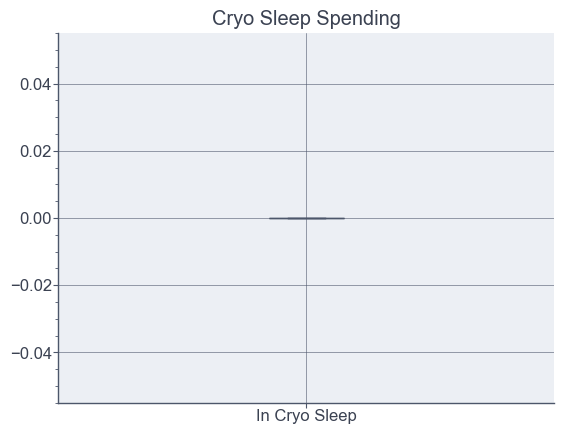

In [62]:
plt.boxplot([df_fe[df_fe.CryoSleep == True]["Total spend"].values], patch_artist=True, tick_labels=["In Cryo Sleep"])
plt.title("Cryo Sleep Spending")
plt.show()

High spenders vs low spenders

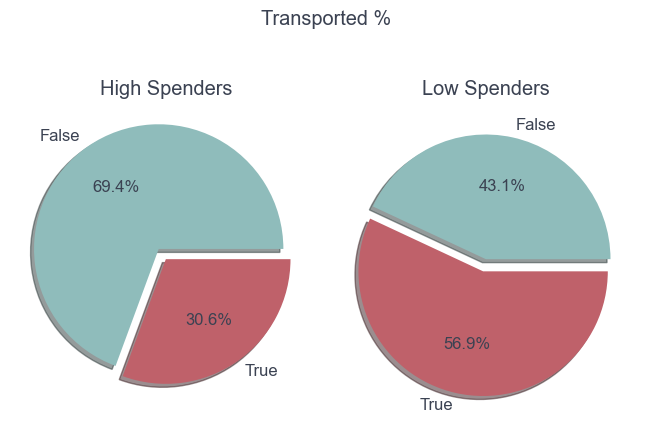

In [63]:
total_spend_mean = df_fe["Total spend"].mean()
high_spenders_df = df_fe[df_fe["Total spend"] > total_spend_mean]
low_spenders_df = df_fe[df_fe["Total spend"] < total_spend_mean]

high_spenders_stats = high_spenders_df.groupby("Transported")["Total spend"].size() / high_spenders_df["Total spend"].count()
low_spenders_stats = low_spenders_df.groupby("Transported")["Total spend"].size() / low_spenders_df["Total spend"].count()

fig, axes = plt.subplots(nrows=1, ncols=2, constrained_layout=True)
axes[0].pie(high_spenders_stats.values, labels=high_spenders_stats.index, autopct="%1.1f%%", explode=(0.1, 0), shadow=True)
axes[0].set_title("High Spenders")
axes[1].pie(low_spenders_stats.values, labels=low_spenders_stats.index, autopct="%1.1f%%", explode=(0, 0.1), shadow=True)
axes[1].set_title("Low Spenders")

fig.suptitle("Transported %")
plt.show()

## Group Analysis

Transport rate per group

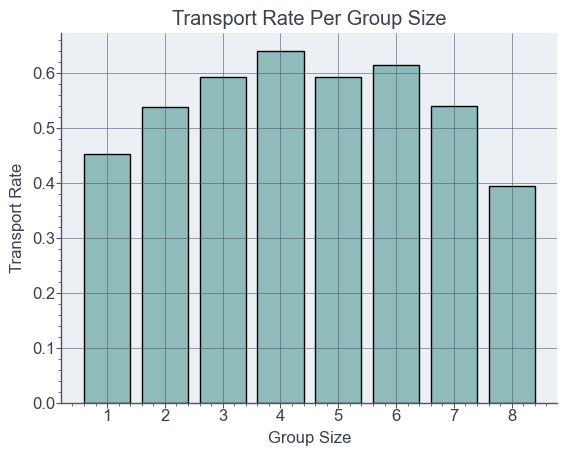

In [64]:
transport_rates_per_group = df_fe.groupby("Group size").Transported.mean()

plt.bar(transport_rates_per_group.index, transport_rates_per_group.values, edgecolor="black")
plt.title("Transport Rate Per Group Size")
plt.xlabel("Group Size")
plt.ylabel("Transport Rate")
plt.show()

Is being alone risky?

In [65]:
pd.crosstab(df_fe["Is alone"], df_fe.Transported, normalize="index")

Transported,False,True
Is alone,,
False,0.433128,0.566872
True,0.547555,0.452445


## Deck And Ship Analysis

Are some decks safer?

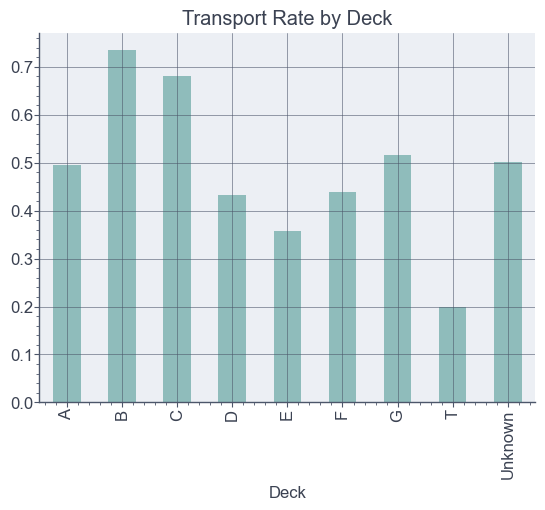

In [66]:
deck_transport_rates = df_fe.groupby("Deck")["Transported"].mean()
deck_transport_rates.plot(kind="bar", title="Transport Rate by Deck")
plt.show()

Is one ship side associated with transportation?

In [67]:
pd.crosstab(df_fe["Side of ship"], df_fe.Transported, normalize="index")

Transported,False,True
Side of ship,,
P,0.548740,0.451260
S,0.444963,0.555037


# EDA Conclusions

## Cleaned Dataset

1.	“Transported” target variable is balanced: True percentage accounted for 50.4%, while False accounted for 49.6%.
2.	“Unknown” values remain low compared to total. Only two columns (Surname, Cabin) had 200 and 199 values, respectively.
3.	Age distribution is positively skewed, meaning less older people compared to younger ones. This is confirmed by the skewness of 0.43.
Furthermore, within age groups, 67% of children are transported, a large percentage compared to the other categories, which range from 46% to 54%, for both classes.


















## Feature Engineered Dataset

1.	When analyzing numerical features (total spend, luxury spending, basic spending and spending per person), the boxplots show many outliers outside the upper bound of the interquartile range (IQR). Furthermore, the upper whisker is longer compared to the lower one, suggesting data is right-skewed. 
2.	Among categorical features, the data shows:
-	66% of passengers coming from Europa are transported, a large proportion compared to the 43% of Earth and the 52% of Mars.
-	61% of people get transported to 55 Cancri e, while the other two destinations’ (PSO J318.5-22, TRAPPIST-1e) percentages are close to 50%.
-	People who pay for VIP service get transported less than those who don’t: 38% vs. 51%, respectively.
-	Cryo sleep has a huge impact on transportation: 82% of those who are asleep get transported.
-	79% of people who don’t spend money are transported, while 70% of people who spend don’t get transported. 
3.	No extremely strong linear correlations are found between numerical variables and the target variable. However, “CryoSleep” (0.46) and “No Spending” (0.48) show moderate positive correlations with transportation.
4.	People in cryo sleep spend little or no money onboard. Furthermore, people who spend more than the average don’t get transported 69.4% of the times compared to the 43.1% of those who spend less than the average.
5.	Regarding group size, people who are in 4 get the highest transport rate, with those in 6 coming second. Furthermore, according to the data, if someone is alone, it doesn’t affect transportation likelihood meaningfully.
6.	Some decks are safer than others: for example, B deck is the most dangerous (73%). Although deck T shows the lowest transport rate, the number of passengers on this desk is very small, making the estimate less reliable. Furthermore, according to the data, one side of the ship doesn’t change transportation probability significantly. 